# Product Demand Analysis

This notebook uses manual filters instead of interactive widgets.

Main focus:
- `category_id`
- `product_id`
- `monthly_demand_units`
- demand share
- month-over-month demand growth


In [12]:
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
sys.path.append(str(project_root / "src"))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from ml_engineering_pyspark.utils.config_loader import load_config

In [13]:
config = load_config(project_root / "configs" / "base.yaml")
monthly_path = project_root / config["paths"]["product_demand_monthly"]

monthly_pdf = pd.read_parquet(monthly_path)
monthly_pdf = monthly_pdf.sort_values(["order_year_month", "product_id"])

monthly_pdf["order_year_month"] = monthly_pdf["order_year_month"].astype(str)
monthly_pdf["category_id"] = monthly_pdf["category_id"].astype("Int64")
monthly_pdf["product_id"] = monthly_pdf["product_id"].astype("Int64")

monthly_pdf.head()

,order_year,order_month,order_year_month,product_id,product_name,category_id,monthly_demand_units,monthly_revenue,monthly_order_count
3,1996,7,1996-07,2,Chang,1,105,1443.999980,3
6,1996,7,1996-07,5,Chef Anton's Gumbo Mix,2,77,1047.199996,2
22,1996,7,1996-07,7,Uncle Bob's Organic Dried Pears,7,15,360.000000,1
31,1996,7,1996-07,11,Queso Cabrales,4,12,168.000000,1
23,1996,7,1996-07,12,Queso Manchego La Pastora,4,12,346.559995,1


In [14]:
# Set filters here.
# Example: selected_category_id = 1
# Example: selected_product_id = 11

selected_category_id = 1
selected_product_id = 2
top_n = 2

In [15]:
df = monthly_pdf.copy()

if selected_category_id is not None:
    df = df[df["category_id"] == selected_category_id]

if selected_product_id is not None:
    df = df[df["product_id"] == selected_product_id]

if selected_product_id is None:
    top_products = (
        df.groupby(["product_id", "product_name"], as_index=False)["monthly_demand_units"]
        .sum()
        .sort_values("monthly_demand_units", ascending=False)
        .head(top_n)
    )
    df = df[df["product_id"].isin(top_products["product_id"])]

df.head()

,order_year,order_month,order_year_month,product_id,product_name,category_id,monthly_demand_units,monthly_revenue,monthly_order_count
3,1996,7,1996-07,2,Chang,1,105,1443.999980,3
99,1996,9,1996-09,2,Chang,1,40,607.999992,1
137,1996,10,1996-10,2,Chang,1,56,680.959989,3
237,1996,12,1996-12,2,Chang,1,25,284.999996,1
270,1997,1,1997-01,2,Chang,1,60,911.999989,1


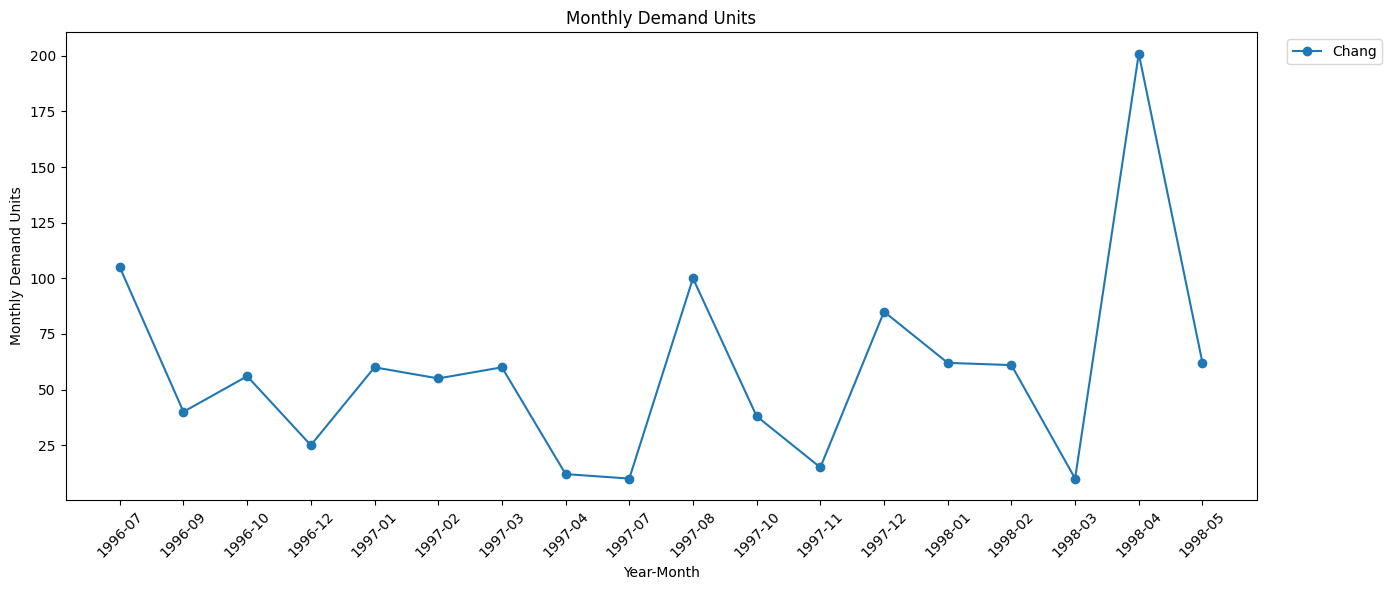

In [16]:
plt.figure(figsize=(14, 6))

for product_name, product_df in df.groupby("product_name"):
    plt.plot(
        product_df["order_year_month"],
        product_df["monthly_demand_units"],
        marker="o",
        label=product_name,
    )

plt.title("Monthly Demand Units")
plt.xlabel("Year-Month")
plt.ylabel("Monthly Demand Units")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

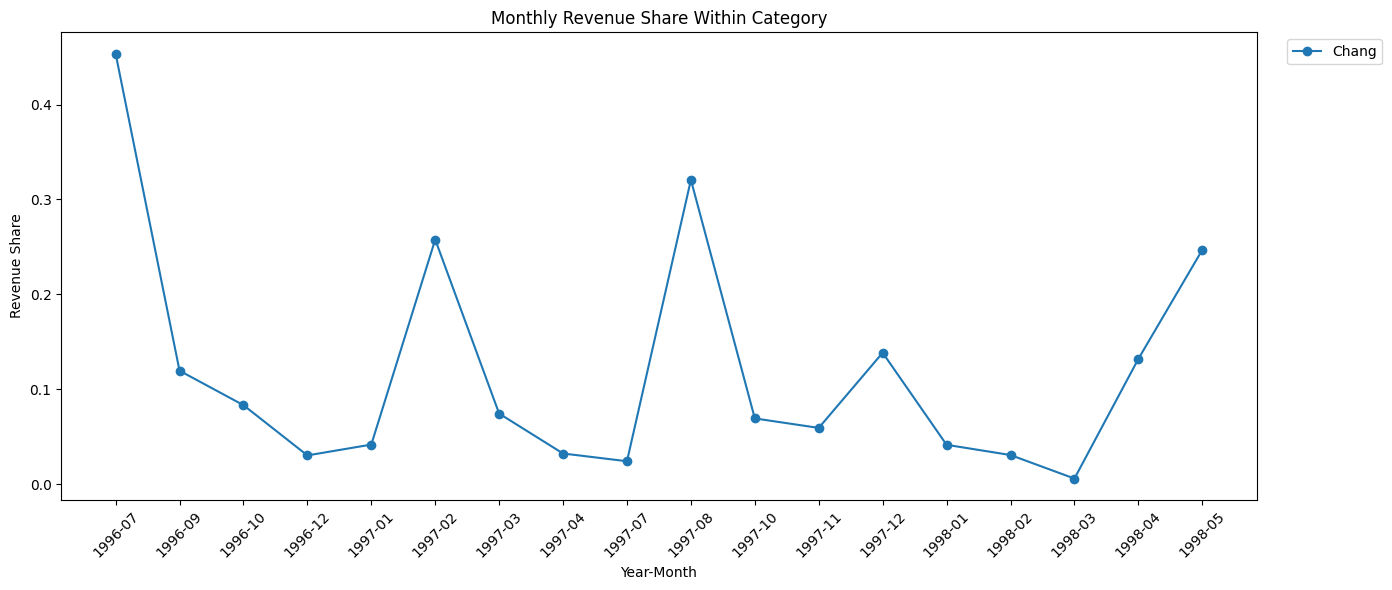

In [25]:
share_df = monthly_pdf.copy()

if selected_category_id is None:
    raise ValueError("Please set selected_category_id before calculating category share.")

share_df = share_df[share_df["category_id"] == selected_category_id].copy()

product_month_revenue = (
    share_df.groupby(
        ["order_year_month", "category_id", "product_id", "product_name"],
        as_index=False
    )["monthly_revenue"]
    .sum()
    .rename(columns={"monthly_revenue": "product_month_revenue"})
)

category_month_revenue = (
    share_df.groupby(
        ["order_year_month", "category_id"],
        as_index=False
    )["monthly_revenue"]
    .sum()
    .rename(columns={"monthly_revenue": "category_month_revenue"})
)

revenue_share_df = product_month_revenue.merge(
    category_month_revenue,
    on=["order_year_month", "category_id"],
    how="left",
)

revenue_share_df["category_revenue_share"] = (
    revenue_share_df["product_month_revenue"] / revenue_share_df["category_month_revenue"]
)

if selected_product_id is not None:
    revenue_share_df = revenue_share_df[
        revenue_share_df["product_id"] == selected_product_id
    ]

plt.figure(figsize=(14, 6))

for product_name, product_df in revenue_share_df.groupby("product_name"):
    plt.plot(
        product_df["order_year_month"],
        product_df["category_revenue_share"],
        marker="o",
        label=product_name,
    )

plt.title("Monthly Revenue Share Within Category")
plt.xlabel("Year-Month")
plt.ylabel("Revenue Share")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


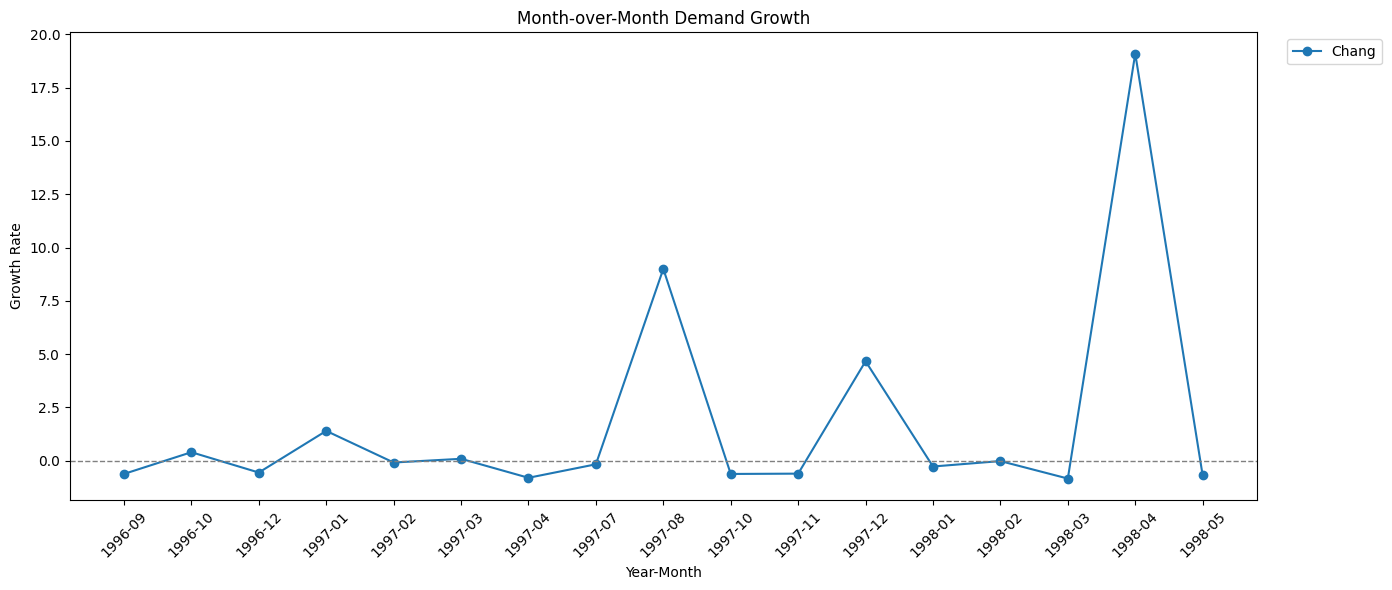

In [19]:
growth_df = df.sort_values(["product_name", "order_year_month"]).copy()
growth_df["demand_growth_rate"] = growth_df.groupby("product_name")["monthly_demand_units"].pct_change()

plt.figure(figsize=(14, 6))

for product_name, product_df in growth_df.groupby("product_name"):
    plt.plot(
        product_df["order_year_month"],
        product_df["demand_growth_rate"],
        marker="o",
        label=product_name,
    )

plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Month-over-Month Demand Growth")
plt.xlabel("Year-Month")
plt.ylabel("Growth Rate")
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [20]:
summary = (
    df.groupby(["product_id", "product_name"], as_index=False)
    .agg(
        total_demand_units=("monthly_demand_units", "sum"),
        total_revenue=("monthly_revenue", "sum"),
        avg_monthly_demand_units=("monthly_demand_units", "mean"),
        avg_monthly_revenue=("monthly_revenue", "mean"),
    )
    .sort_values("total_demand_units", ascending=False)
)

summary

,product_id,product_name,total_demand_units,total_revenue,avg_monthly_demand_units,avg_monthly_revenue
0,2,Chang,1057,16355.959905,58.722222,908.664439
